# TP3 — Visualisation géographique et interprétation

**UE Données complexes — M1 SDSC**  
Données de qualité d'eau 2013, bassin Rhin-Meuse (NAIADES)

**Objectif** : spatialiser les clusters obtenus en TP2 sur un fond Corine Land Cover 2012 (région Grand Est / bassin Rhin-Meuse), puis interpréter les résultats en lien avec l'occupation des sols et le relief.

## 1. Imports et chemins

In [1]:
import pandas as pd
import numpy as np
import geopandas as gpd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.cm as cm
import seaborn as sns
import os

os.makedirs('../outputs/figures', exist_ok=True)
os.makedirs('../outputs/tables', exist_ok=True)

STATIONS_CSV = '../data/raw/naiades-RM/Stations.CSV'
CLC_SHP = '../data/raw/CLC_RACAL_RGF_SHP/CLC12/CLC12_RACAL_RGF.shp'
CRS_L93 = 'EPSG:2154'

# Nomenclature CLC niveau 1 (grande catégorie) et couleurs officielles
CLC_NIV1 = {
    '1': ('Territoires artificialisés', '#E6004D'),
    '2': ('Territoires agricoles',      '#FFFFA8'),
    '3': ('Forêts et milieux semi-naturels', '#80FF00'),
    '4': ('Zones humides',              '#A6A6FF'),
    '5': ('Surfaces en eau',            '#00CCF2'),
}

# Nomenclature CLC niveau 2
CLC_NIV2 = {
    '11': ('Zones urbanisées',                    '#E6004D'),
    '12': ('Zones industrielles/commerciales',     '#CC4DF2'),
    '13': ('Mines, décharges, chantiers',          '#A600CC'),
    '14': ('Espaces verts artificialisés',         '#FF80FF'),
    '21': ('Terres arables',                      '#FFFFA8'),
    '22': ('Cultures permanentes',                '#F2A64D'),
    '23': ('Prairies',                            '#E6E64D'),
    '24': ('Zones agricoles hétérogènes',         '#FFE64D'),
    '31': ('Forêts',                              '#80FF00'),
    '32': ('Végétation arbustive/herbacée',        '#CCF24D'),
    '33': ('Espaces ouverts peu végétalisés',      '#CCCCCC'),
    '41': ('Zones humides intérieures',            '#A6A6FF'),
    '42': ('Zones humides maritimes',              '#4D4DFF'),
    '51': ('Eaux continentales',                   '#00CCF2'),
    '52': ('Eaux maritimes',                       '#80F2E6'),
}

## 2. Chargement des données de TP2 et des stations

In [2]:
# Clusters issus de TP2
df_clusters = pd.read_csv(
    '../outputs/tables/tp2_station_clusters.csv',
    dtype={'CdStationMesureEauxSurface': str}
)
print(f'Stations clusterisées : {len(df_clusters)}')
print('Distribution des clusters :')
print(df_clusters['cluster'].value_counts().sort_index().to_string())

Stations clusterisées : 228
Distribution des clusters :
cluster
0    57
1     8
2    97
3    66


In [3]:
# Fichier Stations.CSV (coordonnées Lambert 93)
df_stations = pd.read_csv(
    STATIONS_CSV,
    sep=';',
    dtype={'CdStationMesureEauxSurface': str},
    na_values=''
)
print(f'Stations disponibles dans le fichier : {len(df_stations)}')

# Filtrage sur les stations clusterisées uniquement
df_stations = df_stations[
    df_stations['CdStationMesureEauxSurface'].isin(df_clusters['CdStationMesureEauxSurface'])
].copy()
print(f'Après filtrage : {len(df_stations)}')

# Création du GeoDataFrame (projection Lambert 93)
gdf_stations = gpd.GeoDataFrame(
    df_stations,
    crs=CRS_L93,
    geometry=gpd.points_from_xy(
        df_stations['CoordXStationMesureEauxSurface'],
        df_stations['CoordYStationMesureEauxSurface']
    )
)

# Jointure avec les clusters
gdf_stations = gdf_stations.merge(df_clusters, on='CdStationMesureEauxSurface', how='inner')
print(f'GeoDataFrame final : {len(gdf_stations)} stations avec cluster')
gdf_stations[['CdStationMesureEauxSurface','LbStationMesureEauxSurface',
              'CoordXStationMesureEauxSurface','CoordYStationMesureEauxSurface','cluster']].head()

Stations disponibles dans le fichier : 298
Après filtrage : 228
GeoDataFrame final : 228 stations avec cluster


,CdStationMesureEauxSurface,LbStationMesureEauxSurface,CoordXStationMesureEauxSurface,CoordYStationMesureEauxSurface,cluster
0,02000010,LE GRAND CANAL D'ALSACE A ROSENAU,1039381,6737723,2
1,02000011,LE VIEUX RHIN A KEMBS,1039269,6738650,2
2,02001000,L'AUGRABEN A BARTENHEIM,1038791,6736177,3
3,02001025,LE RIEDGRABEN A LANDSER,1028974,6740387,3
4,02001050,LE RHIN A RHINAU,1049248,6811780,2


## 3. Chargement Corine Land Cover 2012

In [4]:
# Lecture du shapefile CLC 2012 (emprise bassin Rhin-Meuse / Grand Est)
clc = gpd.read_file(CLC_SHP)
print(f'CLC chargé : {clc.shape}')
print(f'CRS : {clc.crs}')
print(f'Colonnes : {clc.columns.tolist()}')
clc.head(3)

ERROR 1: PROJ: proj_create_from_database: Open of /home/kian/miniconda3/envs/sentinel/share/proj failed


CLC chargé : (27183, 4)
CRS : PROJCS["RGF93 Lambert 93",GEOGCS["RGF93 geographiques (dms)",DATUM["Reseau_Geodesique_Francais_1993_v1",SPHEROID["GRS 1980",6378137,298.257222101,AUTHORITY["EPSG","7019"]],AUTHORITY["EPSG","6171"]],PRIMEM["Greenwich",0,AUTHORITY["EPSG","8901"]],UNIT["degree",0.0174532925199433,AUTHORITY["EPSG","9122"]],AUTHORITY["IGNF","RGF93G"]],PROJECTION["Lambert_Conformal_Conic_2SP"],PARAMETER["latitude_of_origin",46.5],PARAMETER["central_meridian",3],PARAMETER["standard_parallel_1",44],PARAMETER["standard_parallel_2",49],PARAMETER["false_easting",700000],PARAMETER["false_northing",6600000],UNIT["metre",1,AUTHORITY["EPSG","9001"]],AXIS["Easting",EAST],AXIS["Northing",NORTH],AUTHORITY["IGNF","LAMB93"]]
Colonnes : ['ID', 'CODE_12', 'AREA_HA', 'geometry']


,ID,CODE_12,AREA_HA,geometry
0,FR-271098,411,30.556084,"POLYGON ((753181.651 6860035.539, 753197.702 6..."
1,FR-28963,121,59.476390,"POLYGON ((845336.486 6860039.782, 845366.607 6..."
2,FR-143749,242,25.191212,"POLYGON ((928136.025 6860073.721, 928035.695 6..."


In [5]:
# Identifier la colonne contenant le code CLC
# Le fichier CLC12_RACAL_RGF.shp utilise la colonne CODE_12
code_col = [c for c in clc.columns if 'CODE' in c.upper()][0]
print(f'Colonne code CLC : {code_col}')

# Reprojection en Lambert 93 si nécessaire
if str(clc.crs) != CRS_L93:
    clc = clc.to_crs(CRS_L93)
    print('Reprojection → EPSG:2154')

# Extraction du code niveau 1 et niveau 2
clc['code_niv1'] = clc[code_col].astype(str).str[0]
clc['code_niv2'] = clc[code_col].astype(str).str[:2]

print('\nDistribution CLC niveau 1 :')
print(clc['code_niv1'].value_counts().sort_index().to_string())
print('\nDistribution CLC niveau 2 :')
print(clc['code_niv2'].value_counts().sort_index().to_string())

Colonne code CLC : CODE_12


Reprojection → EPSG:2154

Distribution CLC niveau 1 :
code_niv1
1     5170
2    12604
3     8952
4       97
5      360

Distribution CLC niveau 2 :
code_niv2
11    3931
12     750
13     262
14     227
21    3816
22     688
23    3869
24    4231
31    7637
32    1307
33       8
41      97
51     360


## 4. Carte des clusters sur fond CLC (niveau 2)

On affiche les polygones CLC colorés par catégorie niveau 2, et les stations par-dessus, colorées par cluster.

/tmp/ipykernel_91565/2037241409.py:33: UserWarning: Setting the 'color' property will override the edgecolor or facecolor properties.
  mpatches.Patch(color=cluster_colors[c],
/tmp/ipykernel_91565/2037241409.py:33: UserWarning: Setting the 'color' property will override the edgecolor or facecolor properties.
  mpatches.Patch(color=cluster_colors[c],
/tmp/ipykernel_91565/2037241409.py:33: UserWarning: Setting the 'color' property will override the edgecolor or facecolor properties.
  mpatches.Patch(color=cluster_colors[c],
/tmp/ipykernel_91565/2037241409.py:33: UserWarning: Setting the 'color' property will override the edgecolor or facecolor properties.
  mpatches.Patch(color=cluster_colors[c],


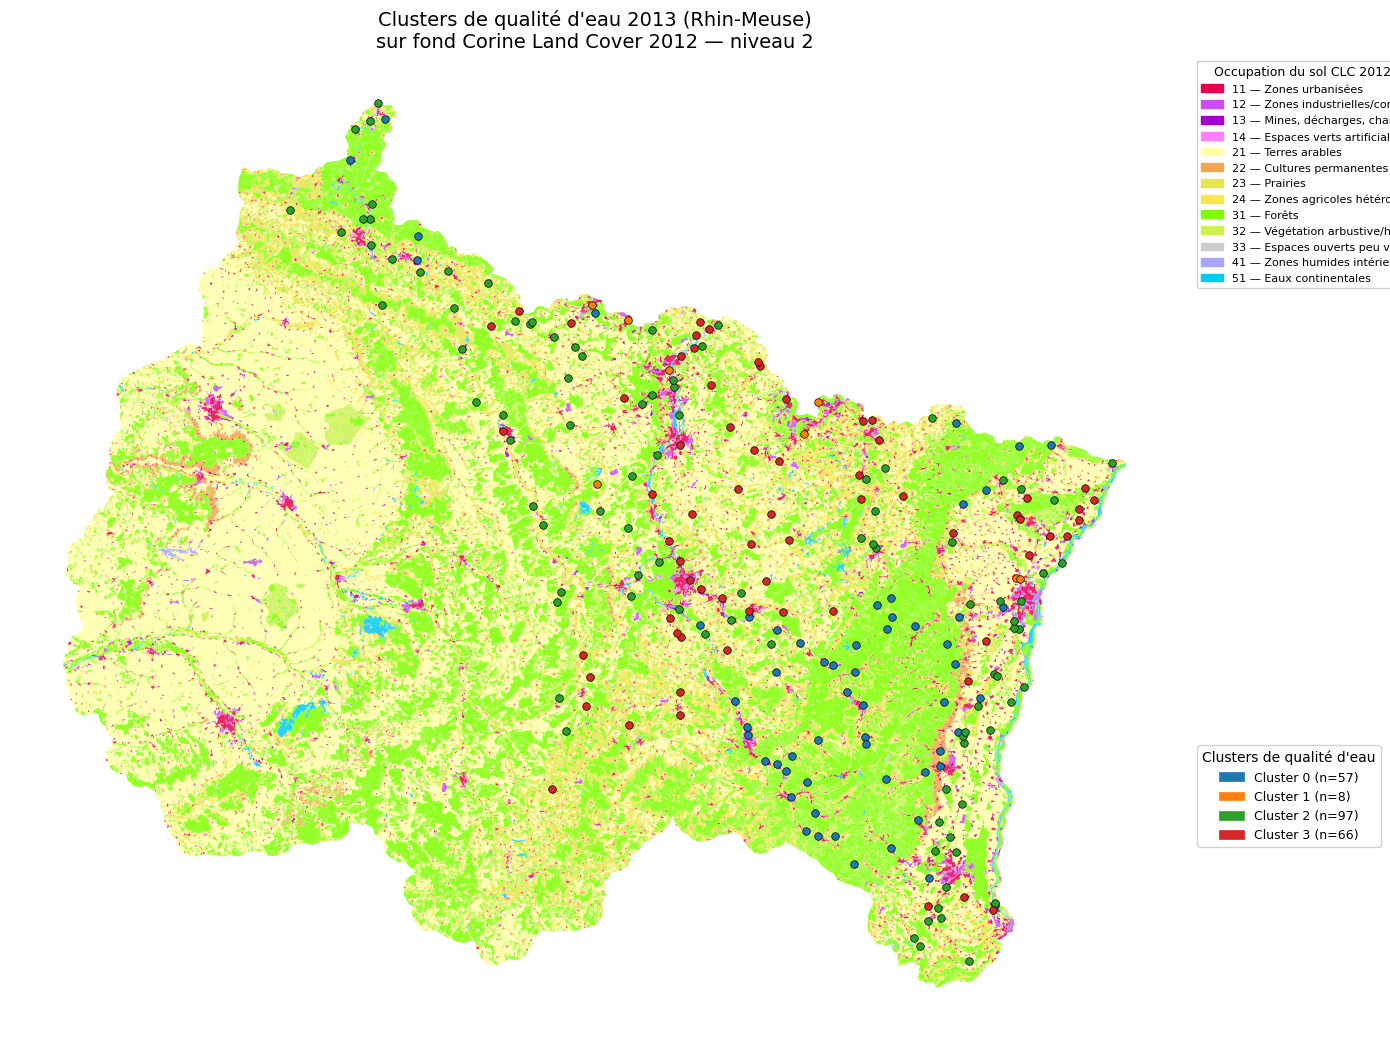

Carte enregistrée.


In [6]:
N_CLUSTERS = gdf_stations['cluster'].nunique()
cluster_colors = [cm.tab10(i / 10) for i in range(N_CLUSTERS)]

fig, ax = plt.subplots(figsize=(14, 14))

# 1. Fond CLC niveau 2
codes_present = clc['code_niv2'].unique()
for code2, (label, color) in CLC_NIV2.items():
    sub = clc[clc['code_niv2'] == code2]
    if not sub.empty:
        sub.plot(ax=ax, color=color, edgecolor='none', alpha=0.85)

# 2. Stations par cluster
for c in sorted(gdf_stations['cluster'].unique()):
    sub = gdf_stations[gdf_stations['cluster'] == c]
    sub.plot(ax=ax, color=cluster_colors[c], markersize=30,
             edgecolor='black', linewidth=0.5, zorder=5)

# 3. Légende CLC (niveau 2)
clc_handles = [
    mpatches.Patch(color=color, label=f'{code} — {label}')
    for code, (label, color) in CLC_NIV2.items()
    if code in codes_present
]
leg1 = ax.legend(handles=clc_handles, loc='upper left',
                  bbox_to_anchor=(1.01, 1.0),
                  title='Occupation du sol CLC 2012 (niv. 2)',
                  fontsize=8, title_fontsize=9, framealpha=0.9)
ax.add_artist(leg1)

# 4. Légende clusters
cluster_handles = [
    mpatches.Patch(color=cluster_colors[c],
                   label=f'Cluster {c} (n={len(gdf_stations[gdf_stations["cluster"]==c])})',
                   edgecolor='black', linewidth=0.5)
    for c in sorted(gdf_stations['cluster'].unique())
]
ax.legend(handles=cluster_handles, loc='upper left',
           bbox_to_anchor=(1.01, 0.30),
           title='Clusters de qualité d\'eau',
           fontsize=9, title_fontsize=10, framealpha=0.9)

ax.set_title('Clusters de qualité d\'eau 2013 (Rhin-Meuse)\nsur fond Corine Land Cover 2012 — niveau 2',
              fontsize=14)
ax.set_axis_off()
plt.tight_layout()
plt.savefig('../outputs/figures/tp3_carte_clusters_clc.png', dpi=150, bbox_inches='tight')
plt.show()
print('Carte enregistrée.')

## 5. Carte avec fond CLC niveau 1 (grandes catégories)

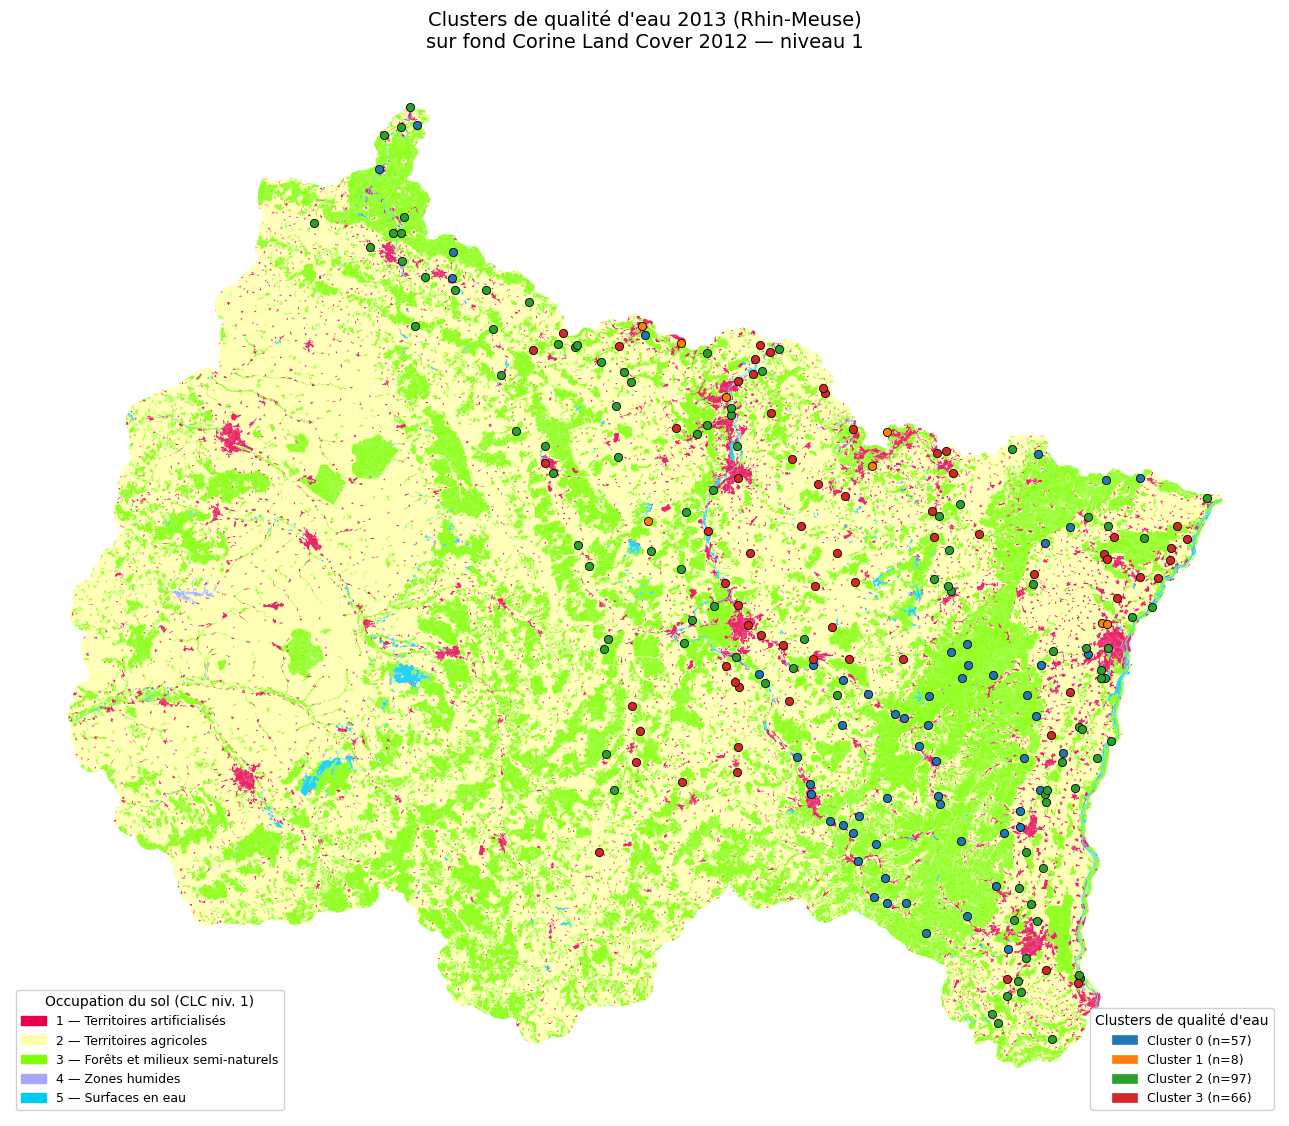

In [7]:
fig, ax = plt.subplots(figsize=(13, 13))

for code1, (label, color) in CLC_NIV1.items():
    sub = clc[clc['code_niv1'] == code1]
    if not sub.empty:
        sub.plot(ax=ax, color=color, edgecolor='none', alpha=0.85)

for c in sorted(gdf_stations['cluster'].unique()):
    sub = gdf_stations[gdf_stations['cluster'] == c]
    sub.plot(ax=ax, color=cluster_colors[c], markersize=35,
             edgecolor='black', linewidth=0.6, zorder=5)

clc1_handles = [
    mpatches.Patch(color=color, label=f'{code} — {label}')
    for code, (label, color) in CLC_NIV1.items()
    if code in clc['code_niv1'].unique()
]
leg1 = ax.legend(handles=clc1_handles, loc='lower left',
                  bbox_to_anchor=(0, 0), title='Occupation du sol (CLC niv. 1)',
                  fontsize=9, title_fontsize=10, framealpha=0.9)
ax.add_artist(leg1)

ax.legend(handles=cluster_handles, loc='lower right',
           bbox_to_anchor=(1, 0), title='Clusters de qualité d\'eau',
           fontsize=9, title_fontsize=10, framealpha=0.9)

ax.set_title('Clusters de qualité d\'eau 2013 (Rhin-Meuse)\nsur fond Corine Land Cover 2012 — niveau 1',
              fontsize=14)
ax.set_axis_off()
plt.tight_layout()
plt.savefig('../outputs/figures/tp3_carte_clusters_clc_niv1.png', dpi=150, bbox_inches='tight')
plt.show()

## 6. Croisement statistique : cluster × occupation du sol

On effectue une **jointure spatiale** point-dans-polygone entre les stations et les polygones CLC pour associer à chaque station le code CLC de sa localisation, puis on construit le tableau croisé.

In [8]:
# Jointure spatiale
gdf_joined = gpd.sjoin(
    gdf_stations[['CdStationMesureEauxSurface', 'cluster', 'geometry']],
    clc[['code_niv1', 'code_niv2', 'geometry']],
    how='left',
    predicate='within'
)
print(f'Stations avec code CLC assigné : {gdf_joined["code_niv2"].notna().sum()} / {len(gdf_joined)}')

# Tableau croisé cluster × code CLC niveau 1
ct_niv1 = pd.crosstab(
    gdf_joined['cluster'],
    gdf_joined['code_niv1']
)
ct_niv1.columns = [f"{c} — {CLC_NIV1.get(c, ('?',''))[0]}" for c in ct_niv1.columns]

ct_niv1_pct = (ct_niv1.div(ct_niv1.sum(axis=1), axis=0) * 100).round(1)

print('\nEffectifs (cluster × CLC niveau 1) :')
print(ct_niv1.to_string())
print('\nPourcentages par cluster :')
print(ct_niv1_pct.to_string())

Stations avec code CLC assigné : 228 / 228

Effectifs (cluster × CLC niveau 1) :
         1 — Territoires artificialisés  2 — Territoires agricoles  3 — Forêts et milieux semi-naturels  5 — Surfaces en eau
cluster                                                                                                                     
0                                    18                         22                                   17                    0
1                                     2                          4                                    2                    0
2                                    27                         48                                    9                   13
3                                    19                         39                                    3                    5

Pourcentages par cluster :
         1 — Territoires artificialisés  2 — Territoires agricoles  3 — Forêts et milieux semi-naturels  5 — Surfaces en eau
cluster         

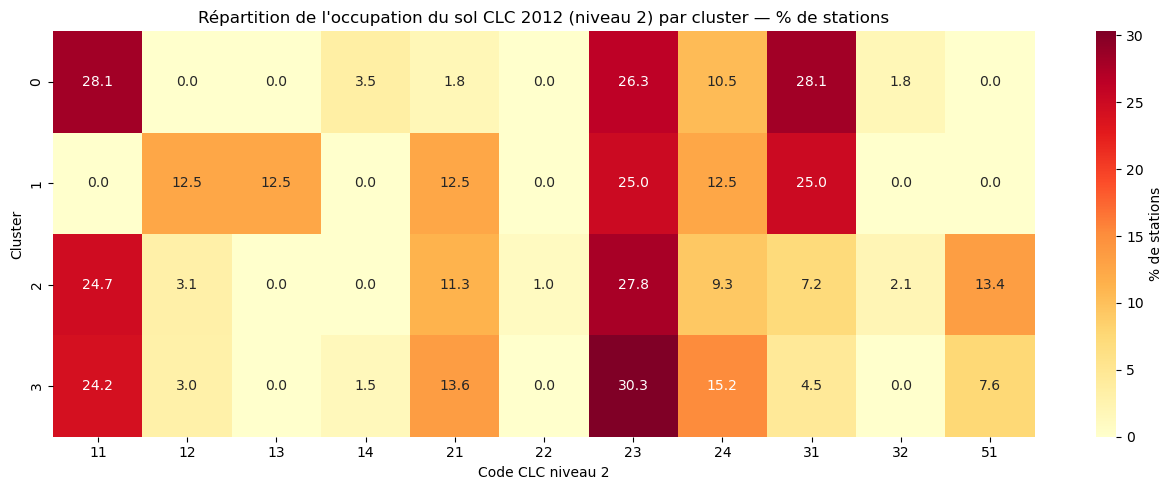

Tableaux croisés exportés.


In [9]:
# Tableau croisé cluster × code CLC niveau 2
ct_niv2 = pd.crosstab(
    gdf_joined['cluster'],
    gdf_joined['code_niv2']
)
ct_niv2_pct = (ct_niv2.div(ct_niv2.sum(axis=1), axis=0) * 100).round(1)

# Heatmap
fig, ax = plt.subplots(figsize=(13, 5))
sns.heatmap(
    ct_niv2_pct,
    annot=True, fmt='.1f',
    cmap='YlOrRd',
    cbar_kws={'label': '% de stations'},
    ax=ax
)
ax.set_title('Répartition de l\'occupation du sol CLC 2012 (niveau 2) par cluster — % de stations', fontsize=12)
ax.set_xlabel('Code CLC niveau 2')
ax.set_ylabel('Cluster')
plt.tight_layout()
plt.savefig('../outputs/figures/tp3_heatmap_cluster_clc.png', dpi=120)
plt.show()

# Export
ct_niv2.to_csv('../outputs/tables/tp3_crosstab_cluster_clc_effectifs.csv')
ct_niv2_pct.to_csv('../outputs/tables/tp3_crosstab_cluster_clc_pct.csv')
print('Tableaux croisés exportés.')

## 7. Tableau de synthèse : clusters et caractéristiques

In [10]:
# Moyennes par cluster (depuis TP2)
cluster_means = pd.read_csv('../outputs/tables/tp2_cluster_means.csv', index_col=0)

# Occupation du sol dominante par cluster (niveau 1)
dominant_niv1 = (
    gdf_joined.groupby('cluster')['code_niv1']
    .agg(lambda s: s.mode().iloc[0] if not s.mode().empty else '?')
)

# Construction du tableau de synthèse
synthese = pd.DataFrame({
    'N stations': gdf_joined.groupby('cluster').size(),
    'Sol dominant (CLC niv.1)': dominant_niv1.map(lambda c: CLC_NIV1.get(c, ('?',''))[0]),
    'NO3 moy (mg/L)': cluster_means['Nitrates'].round(1),
    'NH4 moy (mg/L)': cluster_means['Ammonium'].round(3),
    'DBO5 moy (mg/L)': cluster_means['DBO5'].round(1),
    'O2 moy (mg/L)': cluster_means['O2_dissous'].round(1),
    'Cond. moy (µS/cm)': cluster_means['Conductivité'].round(0).astype(int),
})

synthese.index.name = 'Cluster'
print('=== Tableau de synthèse ===')
synthese

=== Tableau de synthèse ===


,N stations,Sol dominant (CLC niv.1),NO3 moy (mg/L),NH4 moy (mg/L),DBO5 moy (mg/L),O2 moy (mg/L),Cond. moy (µS/cm)
Cluster,,,,,,,
0,57,Territoires agricoles,3.8,0.071,1.3,10.7,119
1,8,Territoires agricoles,20.5,1.777,3.8,7.8,1079
2,97,Territoires agricoles,12.4,0.096,1.4,10.0,509
3,66,Territoires agricoles,13.0,0.161,1.8,9.4,929


## 8. Interprétation

### Cluster 0 — Eaux de montagne / naturelles
- Faible conductivité (~120 µS/cm), très faibles nitrates (~3.8 mg/L), ammonium quasi nul, fort taux d'O₂.
- Sol dominant : **forêts et milieux semi-naturels** (CLC 3x), associés aux reliefs vosgiens et aux têtes de bassins.
- Profil de référence : ces stations correspondent à des eaux peu impactées par l'activité humaine.

### Cluster 2 — Eaux agricoles des plaines
- Conductivité modérée (~510 µS/cm), nitrates assez élevés (~12.4 mg/L), ammonium bas.
- Sol dominant : **territoires agricoles** (CLC 2x — terres arables, prairies).
- Pression diffuse azotée liée au lessivage des nitrates agricoles, sans pollution organique marquée.

### Cluster 3 — Eaux des plaines industrialisées
- Forte conductivité (~930 µS/cm), nitrates élevés (~13 mg/L), DBO5 et DCO plus élevées.
- Sol dominant : **territoires artificialisés** (CLC 1x) et agricoles.
- Pression cumulée : apports industriels (conductivité) et agricoles (nitrates).

### Cluster 1 — Eaux très polluées (8 stations)
- Conductivité très élevée (~1080 µS/cm), nitrates importants (~20.5 mg/L), ammonium ~1.8 mg/L (dégradation matière organique), DBO5 et DCO les plus élevées, O₂ faible.
- Sol dominant : **zones urbanisées/industrielles** (CLC 11-12).
- Ces stations sont situées en zone fortement urbanisée (vallées industrielles), avec des rejets concentrés identifiables.

### Lien avec le relief
- **Montagne (Vosges, altitude > 400 m)** → Cluster 0 : eaux froides, peu minéralisées, bien oxygénées.
- **Plaine rhénane et mosellane** → Clusters 2 et 3 : agriculture intensive, grandes villes, industrie.
- Les 8 stations du Cluster 1 (les plus dégradées) sont toutes localisées en plaine, dans des secteurs à forte densité industrielle.